<div align="center">

# 🔎 Indonesian News Fact-Checker: IndoBERT & Entailment Verification (NLI)
### Fact-Checker Berita Berbahasa Indonesia Menggunakan IndoBERT dan Entailment Verification (NLI)

**Project UTS — Natural Language Processing · Semester 7**

</div>

| | |
|---|---|
| **Tugas** | Verifikasi otomatis klaim berbahasa Indonesia terhadap korpus berita |
| **Korpus** | 32.000 artikel bersih dari 7 portal berita nasional (Maret–April 2023) |
| **Metode** | Hybrid retrieval (BM25 + Sentence-BERT + RRF) → IndoBERT & Entailment Verification (NLI) → agregasi FEVER-style → SHAP |
| **Output** | Verdict `SUPPORTED` / `REFUTED` / `NOT ENOUGH INFO`, confidence, evidence bersumber, dan penjelasan kata |
| **Kode** | Package `fact_checker/` — notebook ini **mengimpor** package tersebut, sehingga hasil notebook = CLI = web app |

---

### Daftar Isi
1. [Pendahuluan](#1.-Pendahuluan)
2. [Setup & Konfigurasi](#2.-Setup-&-Konfigurasi)
3. [Exploratory Data Analysis](#3.-Exploratory-Data-Analysis)
4. [Preprocessing](#4.-Preprocessing)
5. [Memuat Sistem](#5.-Memuat-Sistem)
6. [Tahap 1–2: Hybrid Retrieval & Passage Selection](#6.-Tahap-1–2:-Hybrid-Retrieval-&-Passage-Selection)
7. [Tahap 3: IndoBERT & Entailment Verification (NLI)](#7.-Tahap-3:-IndoBERT-&-Entailment-Verification-(NLI))
8. [Tahap 4: Agregasi Verdict & Demo End-to-End](#8.-Tahap-4:-Agregasi-Verdict-&-Demo-End-to-End)
9. [Tahap 5: Explainable AI (SHAP)](#9.-Tahap-5:-Explainable-AI-(SHAP))
10. [Evaluasi Kuantitatif](#10.-Evaluasi-Kuantitatif)
11. [Analisis Sensitivitas & Kesalahan](#11.-Analisis-Sensitivitas-&-Kesalahan)
12. [Web App](#12.-Web-App)
13. [Kesimpulan](#13.-Kesimpulan)


## 1. Pendahuluan

**Latar belakang.** Penyebaran hoaks di media sosial Indonesia bergerak jauh lebih cepat daripada kemampuan
pemeriksa fakta manual. Sistem *automated fact-checking* membantu dengan cara mencari bukti dari sumber
tepercaya lalu menilai apakah bukti tersebut **mendukung** atau **membantah** sebuah klaim.

**Rumusan masalah.** Diberikan klaim $c$ dan korpus berita $\mathcal{D}$, tentukan verdict
$y \in \{\text{SUPPORTED}, \text{REFUTED}, \text{NOT\_ENOUGH\_INFO}\}$ beserta bukti $E \subset \mathcal{D}$
dan penjelasannya.

**Pendekatan (mengikuti paradigma FEVER — Thorne et al., 2018):**

```text
 Klaim ─▶ ① Article Retrieval ─▶ ② Passage Selection ─▶ ③ IndoBERT & NLI ─▶ ④ Agregasi ─▶ Verdict
          BM25 + SBERT + RRF      window 3 kalimat        IndoBERT NLI          max + ambang      │
                                                                                         ▼
                                                                         ⑤ SHAP pada evidence penentu
```

| Tahap | Pilihan desain | Alasan |
|---|---|---|
| Preprocessing | pembersihan boilerplate 7 portal, segmentasi kalimat sadar singkatan | teks hasil scraping penuh noise |
| ① Retrieval | BM25 ⊕ Sentence-BERT via Reciprocal Rank Fusion | BM25 kuat untuk nama & angka, SBERT kuat untuk parafrase |
| ② Passage | sliding window 3 kalimat, diurutkan cosine similarity | premis NLI harus fokus dan muat batas token |
| ③ NLI & Verifikasi | IndoBERT NLI (`LazarusNLP/indobert-lite-base-p1-indonli`) | dilatih khusus pada benchmark **IndoNLI** (Mahendra et al., 2021) untuk bahasa Indonesia |
| ④ Agregasi | *max* dengan gerbang relevansi dan ambang 0,60 | satu bukti kuat tidak "diencerkan" evidence netral |
| ⑤ XAI | SHAP Partition Explainer | transparansi keputusan model |


## 2. Setup & Konfigurasi

In [1]:
import sys, os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

ROOT = Path.cwd().parent if Path.cwd().name == "notebook_version" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown, Image
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()

# Gaya grafik yang konsisten di seluruh notebook
C = {"blue": "#2563eb", "green": "#16a34a", "red": "#dc2626", "amber": "#d97706",
     "violet": "#7c3aed", "slate": "#64748b"}
LABEL_COLOR = {"ENTAILMENT": C["green"], "NEUTRAL": C["amber"], "CONTRADICTION": C["red"],
               "SUPPORTED": C["green"], "NOT_ENOUGH_INFO": C["amber"], "REFUTED": C["red"]}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
                     "axes.grid": True, "grid.alpha": .25, "grid.linestyle": "--"})
pd.set_option("display.max_colwidth", 110)

import fact_checker
from fact_checker.config import Config, resolve_device, VERDICTS, NLI_LABELS
cfg = Config()

env = {"fact_checker": fact_checker.__version__, "Python": sys.version.split()[0],
       "PyTorch": torch.__version__, "Device": resolve_device(), "CPU threads": torch.get_num_threads()}
display(pd.DataFrame(env, index=["versi"]).T)

,versi
fact_checker,2.0.0
Python,3.14.7
PyTorch,2.14.0+cpu
Device,cpu
CPU threads,8


In [2]:
# Seluruh hyper-parameter berasal dari fact_checker/config.py
keys = ["embedding_model", "nli_model", "top_articles", "top_passages", "passage_sentences",
        "passage_stride", "max_passages_per_article", "rrf_k", "bm25_k1", "bm25_b", "aggregation",
        "relevance_threshold", "support_threshold", "refute_threshold", "shap_max_evals"]
display(pd.DataFrame({"nilai": {k: getattr(cfg, k) for k in keys}}))

,nilai
embedding_model,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
nli_model,LazarusNLP/indobert-lite-base-p1-indonli
top_articles,8
top_passages,5
passage_sentences,3
passage_stride,2
max_passages_per_article,2
rrf_k,60
bm25_k1,1.5
bm25_b,0.75


## 3. Exploratory Data Analysis
Kolom yang dipakai: `id, source, title, url, date, content, summary`. Kolom `embedding` (vektor 1536 dimensi
bawaan dataset) **tidak dipakai**: dibuat oleh model komersial yang tidak tersedia offline, sehingga klaim
pengguna tidak dapat di-embed ke ruang vektor yang sama.

In [3]:
raw = pd.read_csv(ROOT / "data.csv", usecols=["id", "source", "title", "url", "content", "date", "summary"])
raw["n_words"] = raw.content.fillna("").str.split().str.len()
raw["n_words_summary"] = raw.summary.fillna("").str.split().str.len()
raw["day"] = pd.to_datetime(raw.date.str[:10], errors="coerce")

overview = pd.Series({
    "Artikel (baris mentah)": f"{len(raw):,}",
    "Portal berita": raw.source.nunique(),
    "Content kosong": f"{raw.content.isna().sum():,}",
    "Content duplikat": f"{raw.content.duplicated().sum():,}",
    "Rentang tanggal": f"{raw.day.min():%d %b %Y} – {raw.day.max():%d %b %Y}",
    "Median panjang artikel": f"{raw.n_words.median():.0f} kata",
    "Median panjang ringkasan": f"{raw.n_words_summary.median():.0f} kata",
}, name="nilai")
display(overview.to_frame())

,nilai
Artikel (baris mentah),"32,735"
Portal berita,7
Content kosong,441
Content duplikat,648
Rentang tanggal,10 Aug 2018 – 11 Apr 2023
Median panjang artikel,288 kata
Median panjang ringkasan,62 kata


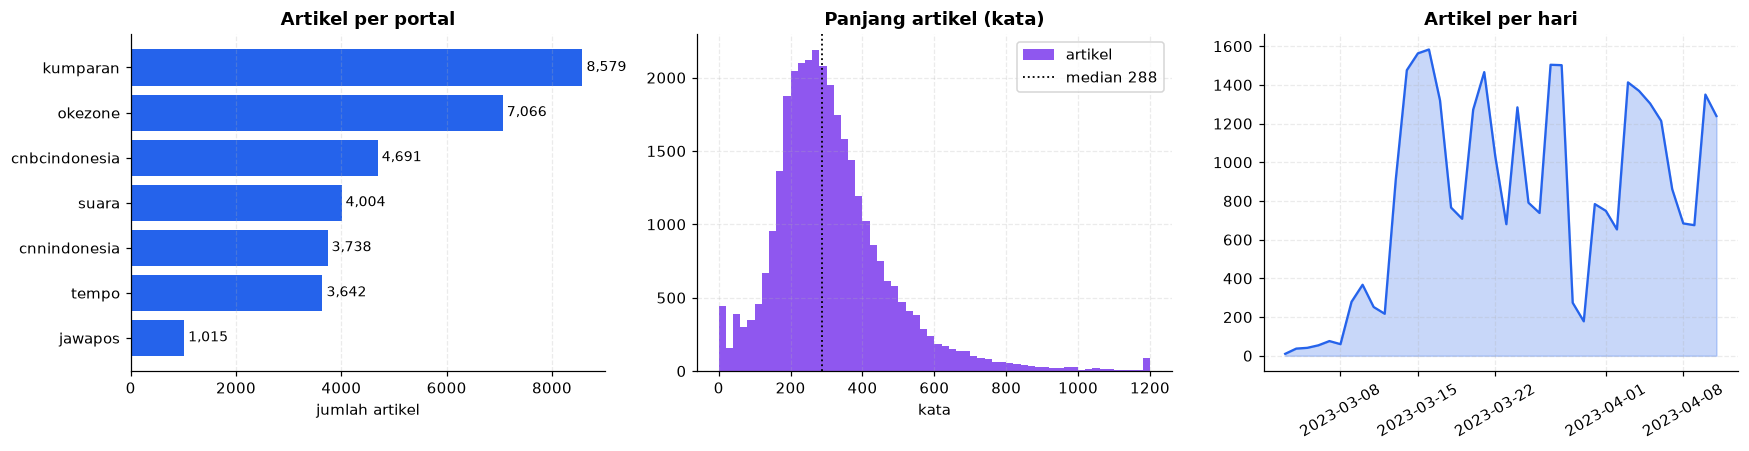

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
vc = raw.source.value_counts().sort_values()
axes[0].barh(vc.index, vc.values, color=C["blue"])
for i, v in enumerate(vc.values): axes[0].text(v, i, f" {v:,}", va="center", fontsize=9)
axes[0].set_title("Artikel per portal"); axes[0].set_xlabel("jumlah artikel"); axes[0].grid(axis="y")

axes[1].hist(raw.n_words.clip(upper=1200), bins=60, color=C["violet"], alpha=.85, label="artikel")
axes[1].axvline(raw.n_words.median(), color="black", ls=":", lw=1.2, label=f"median {raw.n_words.median():.0f}")
axes[1].set_title("Panjang artikel (kata)"); axes[1].set_xlabel("kata"); axes[1].legend()

daily = raw[raw.day >= "2023-03-01"].groupby("day").size()
axes[2].fill_between(daily.index, daily.values, color=C["blue"], alpha=.25)
axes[2].plot(daily.index, daily.values, color=C["blue"], lw=1.5)
axes[2].set_title("Artikel per hari"); axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Temuan EDA**
* Korpus didominasi Kumparan dan Okezone; seluruh berita (kecuali 1 artikel) terbit **Maret–April 2023** →
  klaim di luar periode ini secara alami akan berujung *Not Enough Info*.
* Median artikel ±290 kata ≫ batas 128 token model embedding MiniLM. Karena itu representasi dense memakai
  **judul + ringkasan**, sedangkan NLI bekerja pada **passage** pendek — bukan artikel utuh.

## 4. Preprocessing
Boilerplate yang dibersihkan: dateline (`TEMPO.CO, Jakarta -`, `JAKARTA -`, `Suara.com -`), footer
(`Pilihan Editor:`, `Ikuti berita terkini…`), penanda `Baca juga:`, embed `[Gambas:Video CNN]`, e-mail tersamar,
hashtag, kode penulis `(wal)`, serta kalimat yang menempel (`tewas."Presiden`).

In [5]:
from fact_checker.preprocessing import clean_text, split_sentences, make_passages
sample = raw.loc[raw.id == 84, "content"].iloc[0]
cleaned = clean_text(sample)
display(pd.DataFrame({"sebelum": [sample[:230] + " …", "… " + sample[-160:]],
                      "sesudah": [cleaned[:230] + " …", "… " + cleaned[-160:]]},
                     index=["awal artikel", "akhir artikel"]))

,sebelum,sesudah
awal artikel,"TEMPO.CO, Jakarta - Presiden Joko Widodo atau Jokowi memerintahkan Wakil Presiden Ma'ruf Amin untuk meninj...",Presiden Joko Widodo atau Jokowi memerintahkan Wakil Presiden Ma'ruf Amin untuk meninjau langsung lokasi k...
akhir artikel,"… wa,"" demikian keterangan BPBD DKI Jakarta, Sabtu, 4 Maret 2024.Pilihan Editor:Profil Depo Pertamina Plum...","… an mencapai 579 jiwa. Mereka tersebar di enam titik pengungsian."" Pengungsi info sementara 579 jiwa,"" de..."


In [6]:
passages = make_passages(cleaned, sentences_per_passage=cfg.passage_sentences, stride=cfg.passage_stride)
print(f"{len(split_sentences(cleaned))} kalimat → {len(passages)} passage "
      f"(window {cfg.passage_sentences} kalimat, stride {cfg.passage_stride})\n")
for i, p in enumerate(passages[:3], 1):
    print(f"[passage {i}] {p}\n")

20 kalimat → 10 passage (window 3 kalimat, stride 2)

[passage 1] Presiden Joko Widodo atau Jokowi memerintahkan Wakil Presiden Ma'ruf Amin untuk meninjau langsung lokasi kebakaran depo Pertamina di Plumpang, Jakarta Utara. Kebakaran besar di lokasi tersebut terjadi pada Jumat malam, 3 Maret 2023, dan mengakibatkan belasan warga di sekitar depo tewas. Presiden tidak ke Plumpang hari ini.

[passage 2] Presiden tidak ke Plumpang hari ini. Tapi, Presiden sudah berkoordinasi dengan Wapres yang akan meninjau hari ini," ujar Deputi Bidang Protokol, Pers, dan Media Sekretariat Presiden Bey Machmudin saat dihubungi, Sabtu, 4 Februari 2023. Selain memerintahkan Ma'ruf Amin, Bey menyebut Jokowi juga telah memberikan arahan kepada Kapolri Jenderal Listyo Sigit Prabowo, Menteri BUMN Erick Thohir, dan Penjabat Gubernur DKI Jakarta Heru Budi Hartono soal kunjungan ke lokasi.

[passage 3] Selain memerintahkan Ma'ruf Amin, Bey menyebut Jokowi juga telah memberikan arahan kepada Kapolri Jenderal Listyo

## 5. Memuat Sistem
Korpus bersih dan embedding artikel di-cache di `cache/` → pemuatan berikutnya hanya beberapa detik.

In [7]:
from fact_checker.pipeline import FactChecker
fc = FactChecker(cfg)
arts = fc.articles
print(f"✔ {len(arts):,} artikel bersih ({len(raw) - len(arts):,} dibuang: kosong/duplikat/<30 kata) · "
      f"dimuat dalam {fc.load_seconds:.1f} detik")
print(f"✔ Matriks embedding artikel : {fc.retriever.article_embeddings.shape}")
print(f"✔ Kosakata BM25             : {len(fc.retriever.bm25.vocab):,} term")

✔ 32,000 artikel bersih (735 dibuang: kosong/duplikat/<30 kata) · dimuat dalam 18.4 detik
✔ Matriks embedding artikel : (32000, 384)
✔ Kosakata BM25             : 123,778 term


## 6. Tahap 1–2: Hybrid Retrieval & Passage Selection

**BM25** (Robertson & Zaragoza, 2009):
$$\text{BM25}(q,d)=\sum_{t\in q}\text{IDF}(t)\cdot\frac{f(t,d)\,(k_1+1)}{f(t,d)+k_1\left(1-b+b\,\frac{|d|}{\text{avgdl}}\right)}$$

**Dense retrieval**: $\;\text{sim}(q,d)=\cos(\mathbf{e}_q,\mathbf{e}_d)$ dengan Sentence-BERT multilingual.

**Reciprocal Rank Fusion** (Cormack et al., 2009) menggabungkan peringkat tanpa perlu menyamakan skala skor:
$$\text{RRF}(d)=\sum_{r\in\{\text{BM25},\,\text{dense}\}}\frac{1}{k+\text{rank}_r(d)},\qquad k=60$$

In [8]:
claim = "Ketua Panpel Arema FC dihukum satu setengah tahun penjara karena Tragedi Kanjuruhan"
rows = []
for method in ["bm25", "dense", "hybrid"]:
    for rank, (idx, score) in enumerate(fc.retriever.search_articles(claim, 5, method), 1):
        rows.append({"metode": method, "rank": rank, "skor": round(score, 4),
                     "portal": arts.at[idx, "source"], "judul": arts.at[idx, "title"][:95]})
display(pd.DataFrame(rows).set_index(["metode", "rank"]))

skor        portal  \
metode rank                          
bm25   1     60.8841       okezone   
       2     58.8946         suara   
       3     58.1765  cnnindonesia   
       4     57.9712         tempo   
       5     57.3106  cnnindonesia   
dense  1      0.8378  cnnindonesia   
       2      0.8322  cnnindonesia   
       3      0.7913  cnnindonesia   
       4      0.7678         tempo   
       5      0.7252  cnnindonesia   
hybrid 1      0.0315  cnnindonesia   
       2      0.0313       okezone   
       3      0.0296  cnnindonesia   
       4      0.0293         suara   
       5      0.0288  cnnindonesia   

                                                                                                       judul  
metode rank                                                                                                   
bm25   1                         Vonis Ketua Panpel Arema Lebih Rendah dari Tuntutan, Begini Reaksi Kejagung  
       2                Beda Vonis Terdakwa Tragedi Kanjuruhan: Dua Polisi Divonis Bebas Bikin Publik Kecewa  
       3                                Vonis 1,5 Tahun Panpel Arema Dinilai Tak Setimpal Jumlah Korban Jiwa  
       4     Vonis Ringan hingga Bebas Terdakwa Tragedi Kanjuruhan, Kilas Balik Peristiwa Tewaskan 135 Orang  
       5                                        Deret Vonis Para Terdakwa Tragedi Kanjuruhan, Ada yang Bebas  
dense  1                                     Security Officer Arema Divonis 1 Tahun Kasus Tragedi Kanjuruhan  
       2                                        Ketua Panpel Arema Divonis 1,5 Tahun Bui di Kasus Kanjuruhan  
       3                              Ketua Panpel Arema Pikir-pikir Banding atas Vonis Bui Kasus Kanjuruhan  
       4                                   Tragedi Kanjuruhan, Ketua Panpel Arema FC Divonis 1 Tahun 6 Bulan  
       5                               Vonis 1 Tahun Penjara atas Tragedi Kanjuruhan yang Tewaskan 135 Orang  
hybrid 1                                     Security Officer Arema Divonis 1 Tahun Kasus Tragedi Kanjuruhan  
       2                         Vonis Ketua Panpel Arema Lebih Rendah dari Tuntutan, Begini Reaksi Kejagung  
       3                                Vonis 1,5 Tahun Panpel Arema Dinilai Tak Setimpal Jumlah Korban Jiwa  
       4                Beda Vonis Terdakwa Tragedi Kanjuruhan: Dua Polisi Divonis Bebas Bikin Publik Kecewa  
       5                                Security Officer Arema Sujud Sambut Vonis Kanjuruhan 1 Tahun Penjara

In [9]:
# Tahap 2: passage paling relevan dari artikel kandidat (maks. 2 per artikel agar sumber beragam)
evs = fc.retriever.retrieve(claim, cfg.top_articles, cfg.top_passages, cfg.max_passages_per_article)
display(pd.DataFrame([{"relevansi": f"{e.relevance:.1%}", "rank artikel": e.article_rank,
                       "portal": e.source, "passage": e.passage[:160] + " …"} for e in evs]))

,relevansi,rank artikel,portal,passage
0,88.4%,2,okezone,"Sebagaimana diketahui, Atas dosanya di Tragedi Kanjuruhan, Ketua Panpel Arema FC divonis penjara 1 tahun 6..."
1,77.7%,8,cnnindonesia,Ketua Panpel Arema FC Abdul Haris divonis bersalah dalam kasus Tragedi Kanjuruhan. Dia dihukum 1 tahun 6 b...
2,74.5%,4,suara,Abdul Haris Abdul Haris yang merupakan Ketua Panpel Arema FC dinyatakan bersalah dan divonis 1 tahun 6 bul...
3,71.8%,3,cnnindonesia,"Dan harapannya ketua PSSI yang baru mengawal ini,"" katanya. Ketua Panpel Arema FC Abdul Haris, dijatuhi di..."
4,71.3%,4,suara,"Namun, vonis bebas terhadap 2 polisi itu dinilai sangat mengecewakan serta mencederai rasa keadilan masyar..."


## 7. Tahap 3: Natural Language Inference
NLI memodelkan $P(y \mid \text{premise}, \text{hypothesis})$ dengan $y \in$ {entailment, neutral, contradiction}.
Cross-encoder membaca `[CLS] premise [SEP] hypothesis [SEP]` sekaligus sehingga atensi dapat menghubungkan
token di kedua kalimat.

### Mengapa model NLI versi lama diganti?
Versi lama memakai `cross-encoder/nli-MiniLM2-L6-H768` yang **hanya dilatih pada data bahasa Inggris**
(SNLI + MultiNLI). Pada teks Indonesia, model tersebut cenderung menebak *entailment* setiap kali kata-kata
klaim mirip dengan evidence — **termasuk untuk klaim hoaks yang jelas bertentangan**.

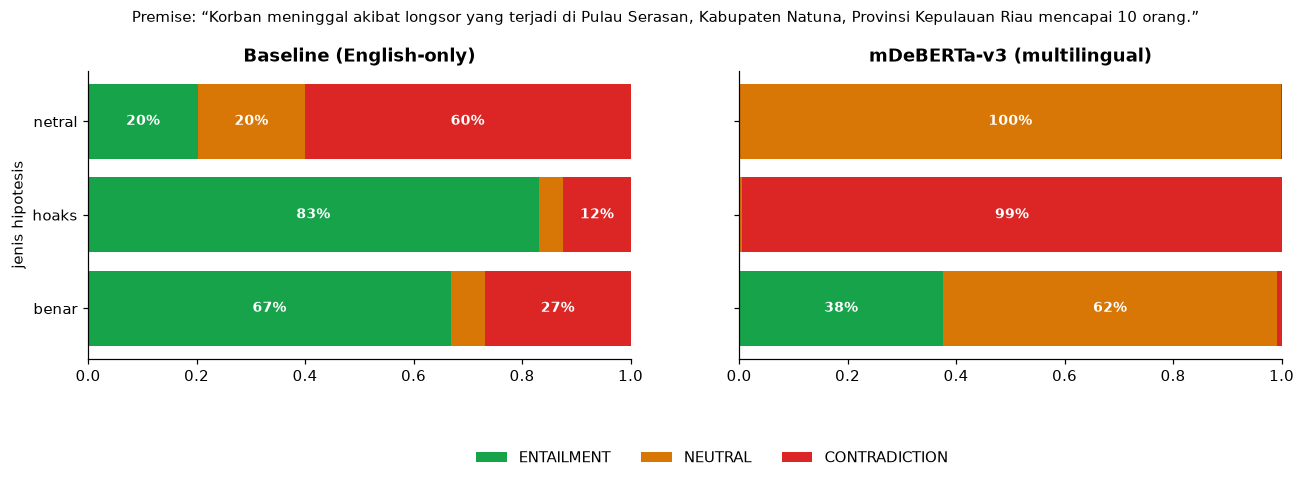

In [10]:
from fact_checker.nli_model import NLIModel
from fact_checker.config import NLI_MODEL_BASELINE
baseline = NLIModel(NLI_MODEL_BASELINE)

premise = ("Korban meninggal akibat longsor yang terjadi di Pulau Serasan, Kabupaten Natuna, "
           "Provinsi Kepulauan Riau mencapai 10 orang.")
hyps = {"benar": "Longsor di Pulau Serasan menewaskan sepuluh orang.",
        "hoaks": "Longsor di Pulau Serasan tidak menelan korban jiwa.",
        "netral": "Longsor di Pulau Serasan dipicu tambang pasir ilegal."}
models = {"Baseline (English-only)": baseline, "IndoBERT NLI (IndoNLI)": fc.nli}

fig, axes = plt.subplots(1, 2, figsize=(14, 3.4), sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    probs = model.predict_proba([premise] * 3, list(hyps.values()))
    left = np.zeros(3)
    for j, lbl in enumerate(NLI_LABELS):
        ax.barh(list(hyps), probs[:, j], left=left, color=LABEL_COLOR[lbl], label=lbl)
        for i in range(3):
            if probs[i, j] > .08:
                ax.text(left[i] + probs[i, j] / 2, i, f"{probs[i, j]:.0%}", ha="center", va="center",
                        color="white", fontsize=9, fontweight="bold")
        left += probs[:, j]
    ax.set_xlim(0, 1); ax.set_title(name); ax.grid(False); ax.invert_yaxis()
axes[0].set_ylabel("jenis hipotesis")
axes[1].legend(loc="lower center", bbox_to_anchor=(-0.05, -0.42), ncol=3, frameon=False)
plt.suptitle(f"Premise: “{premise}”", fontsize=9.5, y=1.04)
plt.show()

Baseline memprediksi klaim **hoaks** sebagai *entailment*, sedangkan IndoBERT NLI membedakan ketiganya dengan tegas.

## 8. Tahap 4: Agregasi Verdict & Demo End-to-End
Untuk evidence relevan $E_r=\{e_i : \text{sim}(c,e_i)\ge\tau_{rel}\}$:
$$S=\max_{e\in E_r}P(\text{ent}\mid e,c),\qquad R=\max_{e\in E_r}P(\text{con}\mid e,c)$$
$$\text{verdict}=\begin{cases}\text{SUPPORTED} & S\ge\tau \wedge S\ge R\\ \text{REFUTED} & R\ge\tau\\ \text{NOT\_ENOUGH\_INFO} & \text{lainnya}\end{cases}
\qquad\tau_{rel}=0{,}35,\ \tau=0{,}60$$
Strategi *mean* (versi lama) merata-rata semua evidence sehingga satu bukti kuat dapat "tenggelam"
oleh passage netral — dibandingkan secara kuantitatif pada Bagian 10.

In [11]:
from fact_checker.display import render_result
result = fc.check("Presiden Jokowi melarang Wakil Presiden Ma'ruf Amin mengunjungi lokasi kebakaran Depo Plumpang.")
render_result(result)

╭─ Klaim ─────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Presiden Jokowi melarang Wakil Presiden Ma'ruf Amin mengunjungi lokasi kebakaran Depo Plumpang.                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ Verdict ───────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  ✘  BERTENTANGAN / HOAKS    confidence 99.8%                                                                    │
│                                                                                                                 │
│ Evidence #1 bertentangan dengan klaim (P(contradiction) = 100%).                                                │
│ Sistem menemukan passage berita yang fakta-faktanya bertentangan dengan klaim (contradiction). Klaim berpotensi │
│ hoaks atau keliru.                                                                                              │
│                                                                                                                 │
│ DIDUKUNG FAKTA        ██░░░░░░░░░░░░░░░░░░░░░░   8.2%                                                           │
│ BERTENTANGAN / HOAKS  ████████████████████████  99.8%                                                           │
│ BUKTI TIDAK CUKUP     ░░░░░░░░░░░░░░░░░░░░░░░░   0.2%                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ Top-5 Evidence ────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│    #   Sumber             Evidence                                         Relevansi   NLI                      │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│    1   tempo              Jokowi Perintahkan Wapres Ma'ruf Amin Tinjau           62%   CONTRADICTION 100%       │
│    ◀   2023-03-04         Lokasi Kebakaran Depo Plumpang                               E 0.00 · N 0.00 · C      │
│                           Presiden Joko Widodo atau Jokowi memerintahkan               1.00                     │
│                           Wakil Presiden Ma'ruf Amin untuk meninjau                                             │
│                           langsung lokasi kebakaran depo Pertamina di                                           │
│                           Plumpang, Jakarta Utara. Kebakaran besar di                                           │
│                           lokasi tersebut terjadi pada Jumat malam, 3                                           │
│                           Maret 2023, dan mengakibatkan belasan warga di                                        │
│                           sekitar depo tewas. Presiden tidak ke Plumpang                                        │
│                           hari ini.                                                                             │
│                                                                                                                 │
│    2   tempo              Depo Pertamina Plumpang Bahaya Dekat                   56%   NEUTRAL 74%              │
│        2023-03-05         Pemukiman, Jokowi: Digeser ke Reklamasi atau                 E 0.08 · N 0.74 · C      │
│                           Warga Direlokasi                                             0.17                     │
│                           Anggota Fraksi PDI Perjuangan DPRD DKI Jakarta                                        │
│                           Gilbert Simanjuntak menyatakan sepatutnya                                             │
│                           mantan Gubernur DKI Jakarta Anies Baswedan                                            │
│                           ikut bertanggungjawab atas kebakaran Depo                                             │
│                           Pertamina Plumpang, Jakarta Utara, pada Jumat                                         │
│                           malam lalu. Menurut Gilbert, sejak awal sudah                                         │
│                           diketahui bahwa lahan di sekitar Depo                                                 │
│                           Pertamina Plumpang tidak boleh ada permukiman                                         │
│                           dalam jarak tertentu. Lahan yang terkena                                              │
│                           kebakaran tadi adalah milik PT Pertamina.                                             │
│                                                                                                                 │
│    3   tempo              Korban Tewas Kebakaran Depo Plumpang 17 Orang,         55%   CONTRADICTION 99%        │
│        2023-03-04         Wapres Ma'ruf Amin: Semua Ditanggung Pertamina               E 0.00 · N 0.01 · C      │
│                           Wakil Presiden Ma'ruf Amin meninjau lokasi                   0.99                     │
│                           kebakaran Depo Pertamina di Plumpang, Jakarta                                         │
│                           Utara pada Sabtu siang, 4 Maret 2023. Dalam                                           │
│                           tinjauan itu, Ma'ruf diteman

╭─ Explainable AI (SHAP) ─────────────────────────────────────────────────────────────────────────────────────────╮
│ Kontribusi kata pada evidence penentu terhadap P(CONTRADICTION)                                                 │
│                                                                                                                 │
│ Presiden Joko Widodo atau Jokowi memerintahkan Wakil Presiden Ma'ruf Amin untuk meninjau langsung lokasi        │
│ kebakaran depo Pertamina di Plumpang, Jakarta Utara. Kebakaran besar di lokasi tersebut terjadi pada Jumat      │
│ malam, 3 Maret 2023, dan mengakibatkan belasan warga di sekitar depo tewas. Presiden tidak ke Plumpang hari ini │
│                                                                                                                 │
│ ▲ meninjau       ■■■■■■■■■■■■■■■■■■■■  +0.2484                                                                  │
│ ▲ langsung       ■■■■■■■■■             +0.1180                                                                  │
│ ▲ Wakil          ■■■■■■■■              +0.1054                                                                  │
│ ▲ Presiden       ■■■■■■■               +0.0908                                                                  │
│ ▲ untuk          ■■■■■■                +0.0806                                                                  │
│ ▲ Amin           ■■■■■                 +0.0720                                                                  │
│ ▲ kebakaran      ■■■■                  +0.0569                                                                  │
│ ▲ Jokowi         ■■■■                  +0.0569                                                                  │
│ ▲ memerintahkan  ■■■■                  +0.0569                                                                  │
│ ▲ lokasi         ■■■■                  +0.0566                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

⏱  retrieval 3.59s · nli 12.91s · explain_shap 220.05s · total 236.56s

In [12]:
demo_claims = [
    "FIFA mencabut status Indonesia sebagai tuan rumah Piala Dunia U-20 2023.",
    "Pemerintah menetapkan 1 Ramadan 1444 H jatuh pada hari Selasa, 21 Maret 2023.",
    "Timnas sepak bola Indonesia dipastikan menjuarai Piala Dunia 2030.",
]
rows = []
for cl in demo_claims:
    r = fc.check(cl, explain=False)
    top = r.decisive_evidence
    rows.append({"klaim": cl, "verdict": r.verdict.label, "confidence": f"{r.verdict.confidence:.1%}",
                 "evidence penentu": f"[{top.source}] {top.title}" if top else "-",
                 "waktu (s)": round(r.timings["total"], 2)})

def color_verdict(v):
    return f"color: {LABEL_COLOR.get(v, 'inherit')}; font-weight: bold"
display(pd.DataFrame(rows).style.map(color_verdict, subset=["verdict"]).hide(axis="index"))

klaim,verdict,confidence,evidence penentu,waktu (s)
FIFA mencabut status Indonesia sebagai tuan rumah Piala Dunia U-20 2023.,SUPPORTED,99.5%,[tempo] Sandiaga-AHY Sebut Sejumlah Kerugian Buntut Indonesia Batal Jadi Tuan Rumah Piala Dunia U-20 2023,22.120000
"Pemerintah menetapkan 1 Ramadan 1444 H jatuh pada hari Selasa, 21 Maret 2023.",REFUTED,96.3%,[cnnindonesia] PBNU Tetapkan 1 Ramadan 1444 H Jatuh pada Kamis 23 Maret,18.750000
Timnas sepak bola Indonesia dipastikan menjuarai Piala Dunia 2030.,REFUTED,66.5%,[kumparan] Sepak Bola dan Politik: Sejarah Perjumpaan Abadi,24.880000


## 9. Tahap 5: Explainable AI (SHAP)
Nilai Shapley kata $i$ pada evidence penentu:
$$\phi_i=\sum_{S\subseteq F\setminus\{i\}}\frac{|S|!\,(|F|-|S|-1)!}{|F|!}\,\big[f(S\cup\{i\})-f(S)\big]$$
dengan $f$ = probabilitas label target dari model NLI dan $F$ = himpunan kata evidence. Nilai positif
(hijau) mendorong prediksi, nilai negatif (merah) melawannya.

In [13]:
from fact_checker.explainability import highlight_html, plot_token_importance, top_tokens
ev = result.decisive_evidence
display(HTML(f"<p><b>Klaim:</b> {result.claim}<br><b>Target:</b> P({result.explanation_target}) · "
             f"<b>Evidence:</b> [{ev.source}] {ev.title}</p>"
             f"<div style='line-height:1.9;font-size:1.05em;padding:10px 14px;border:1px solid #cbd5e1;"
             f"border-radius:8px'>{highlight_html(result.explanation)}</div>"))
fig = plot_token_importance(result.explanation, result.explanation_target,
                            save_path=ROOT / "notebook_version" / "shap_explanation.png")
plt.show()

Kata kerja **memerintahkan** pada evidence adalah kunci yang bertentangan dengan **melarang** pada klaim — sesuai intuisi manusia, menandakan model mengambil keputusan berdasarkan alasan yang tepat.

## 10. Evaluasi Kuantitatif
Benchmark `data/benchmark.jsonl` dibangun dari **15 topik berita** di korpus. Untuk setiap topik dipilih
passage emas **langsung dari `data.csv`**, lalu ditulis tiga klaim: *entailment*, *contradiction*, dan
*neutral*. Ditambah 3 klaim di luar cakupan korpus → **48 kasus**.

| Level | Pertanyaan | Metrik |
|---|---|---|
| NLI (oracle evidence) | Seberapa baik model NLI jika evidence sudah benar? | Accuracy, Macro-F1 |
| Retrieval | Apakah artikel emas terambil? | Recall@k, MRR |
| End-to-end | Apakah verdict akhir sistem benar? | Accuracy, Macro-F1 |

> **Perbaikan bug evaluasi:** versi lama memanggil `classification_report` tanpa argumen `labels`, sehingga
> baris laporan **tertukar** (sklearn mengurutkan label secara alfabetis). Kini urutan label selalu eksplisit
> dan dikunci dengan unit test `tests/test_evaluation.py`.

In [14]:
from fact_checker.evaluation import (load_benchmark, evaluate_nli, evaluate_retrieval,
                                     evaluate_end_to_end, run_pipeline, classification_metrics, save_report)
cases = load_benchmark()
bench = pd.DataFrame([vars(c) for c in cases])
display(bench.groupby("label").size().rename("jumlah kasus").to_frame().T)
display(bench[["topic", "label", "claim"]].head(6))

label,CONTRADICTION,ENTAILMENT,NEUTRAL
jumlah kasus,15,15,18


,topic,label,claim
0,Kebakaran Plumpang: instruksi Presiden,ENTAILMENT,Presiden Jokowi memerintahkan Wakil Presiden Ma'ruf Amin meninjau lokasi kebakaran Depo Pertamina Plumpang.
1,Kebakaran Plumpang: instruksi Presiden,CONTRADICTION,Presiden Jokowi melarang Wakil Presiden Ma'ruf Amin mengunjungi lokasi kebakaran Depo Pertamina Plumpang.
2,Kebakaran Plumpang: instruksi Presiden,NEUTRAL,Wakil Presiden Ma'ruf Amin meninjau lokasi kebakaran Plumpang bersama Gubernur Jawa Barat Ridwan Kamil.
3,Kebakaran Plumpang: jumlah korban,ENTAILMENT,"Hingga 16 Maret 2023, korban meninggal akibat kebakaran Depo Plumpang bertambah menjadi 25 orang."
4,Kebakaran Plumpang: jumlah korban,CONTRADICTION,Kebakaran Depo Plumpang sama sekali tidak menyebabkan korban meninggal dunia.
5,Kebakaran Plumpang: jumlah korban,NEUTRAL,Kebakaran Depo Plumpang dipastikan disebabkan oleh sambaran petir.


### 10.1 NLI dengan evidence emas

In [15]:
results = {"nli": {"indobert": evaluate_nli(fc.nli, cases), "baseline": evaluate_nli(baseline, cases)}}
metric_names = {"accuracy": "Accuracy", "macro_precision": "Macro-P", "macro_recall": "Macro-R", "macro_f1": "Macro-F1"}
nli_tab = pd.DataFrame({results["nli"][k]["model"].split("/")[-1]: {v: results["nli"][k][m] for m, v in metric_names.items()}
                        for k in ["baseline", "indobert"]}).T
display(nli_tab.style.format("{:.3f}").background_gradient(cmap="Blues", axis=None))

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(metric_names)); w = .38
for i, (name, row) in enumerate(nli_tab.iterrows()):
    bars = ax.bar(x + (i - .5) * w, row.values, w, label=name, color=[C["slate"], C["blue"]][i])
    ax.bar_label(bars, fmt="%.2f", fontsize=8.5, padding=2)
ax.set_xticks(x, list(metric_names.values())); ax.set_ylim(0, 1.08); ax.legend(frameon=False)
ax.set_title("NLI pada evidence emas: baseline vs IndoBERT NLI"); plt.show()
print(results["nli"]["indobert"]["report_text"])

,Accuracy,Macro-P,Macro-R,Macro-F1
nli-MiniLM2-L6-H768,0.422,0.278,0.422,0.326
IndoBERT-NLI-IndoBenchmark,0.889,0.891,0.889,0.890


               precision    recall  f1-score   support

   ENTAILMENT      0.933     0.933     0.933        15
      NEUTRAL      0.929     0.867     0.897        15
CONTRADICTION      0.812     0.867     0.839        15

     accuracy                          0.889        45
    macro avg      0.891     0.889     0.890        45
 weighted avg      0.891     0.889     0.890        45



### 10.2 Retrieval

In [16]:
results["retrieval"] = evaluate_retrieval(fc.retriever, cases)
ret = pd.DataFrame(results["retrieval"]).T
display(ret.style.format("{:.3f}").highlight_max(color="#bfdbfe", axis=0))

fig, ax = plt.subplots(figsize=(9, 3.6))
ks = [c for c in ret.columns if c.startswith("recall")]
for method, color in zip(ret.index, [C["amber"], C["violet"], C["blue"]]):
    ax.plot([int(k.split("@")[1]) for k in ks], ret.loc[method, ks], "o-", lw=2, color=color, label=method)
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_ylim(0, 1.05); ax.legend(frameon=False)
ax.set_title("Recall@k artikel emas"); plt.show()

,recall@1,recall@3,recall@5,recall@10,mrr
bm25,0.178,0.400,0.444,0.533,0.293
dense,0.222,0.356,0.444,0.533,0.311
hybrid,0.289,0.511,0.533,0.600,0.398


### 10.3 End-to-end & ablasi strategi agregasi

In [17]:
runs, sec_per_claim = run_pipeline(fc, cases)
results["end_to_end"] = e2e = evaluate_end_to_end(fc, cases, runs=runs, seconds_per_claim=sec_per_claim)
tab = pd.DataFrame({s: {"Accuracy": m["accuracy"], "Macro-F1": m["macro_f1"]} for s, m in e2e["strategies"].items()}).T
tab.index.name = "strategi"
display(tab.style.format("{:.3f}").highlight_max(color="#bbf7d0", axis=0))
print(f"Evidence emas terambil (top-{cfg.top_passages} passage): {e2e['evidence_recall']:.1%} · "
      f"{e2e['seconds_per_claim']:.2f} detik/klaim\n")
print(e2e["strategies"]["max"]["report_text"])

,Accuracy,Macro-F1
strategi,,
max,0.667,0.655
weighted,0.667,0.660
mean,0.688,0.686


Evidence emas terambil (top-5 passage): 44.4% · 14.43 detik/klaim

                 precision    recall  f1-score   support

      SUPPORTED      0.688     0.733     0.710        15
        REFUTED      0.583     0.933     0.718        15
NOT_ENOUGH_INFO      0.875     0.389     0.538        18

       accuracy                          0.667        48
      macro avg      0.715     0.685     0.655        48
   weighted avg      0.725     0.667     0.648        48



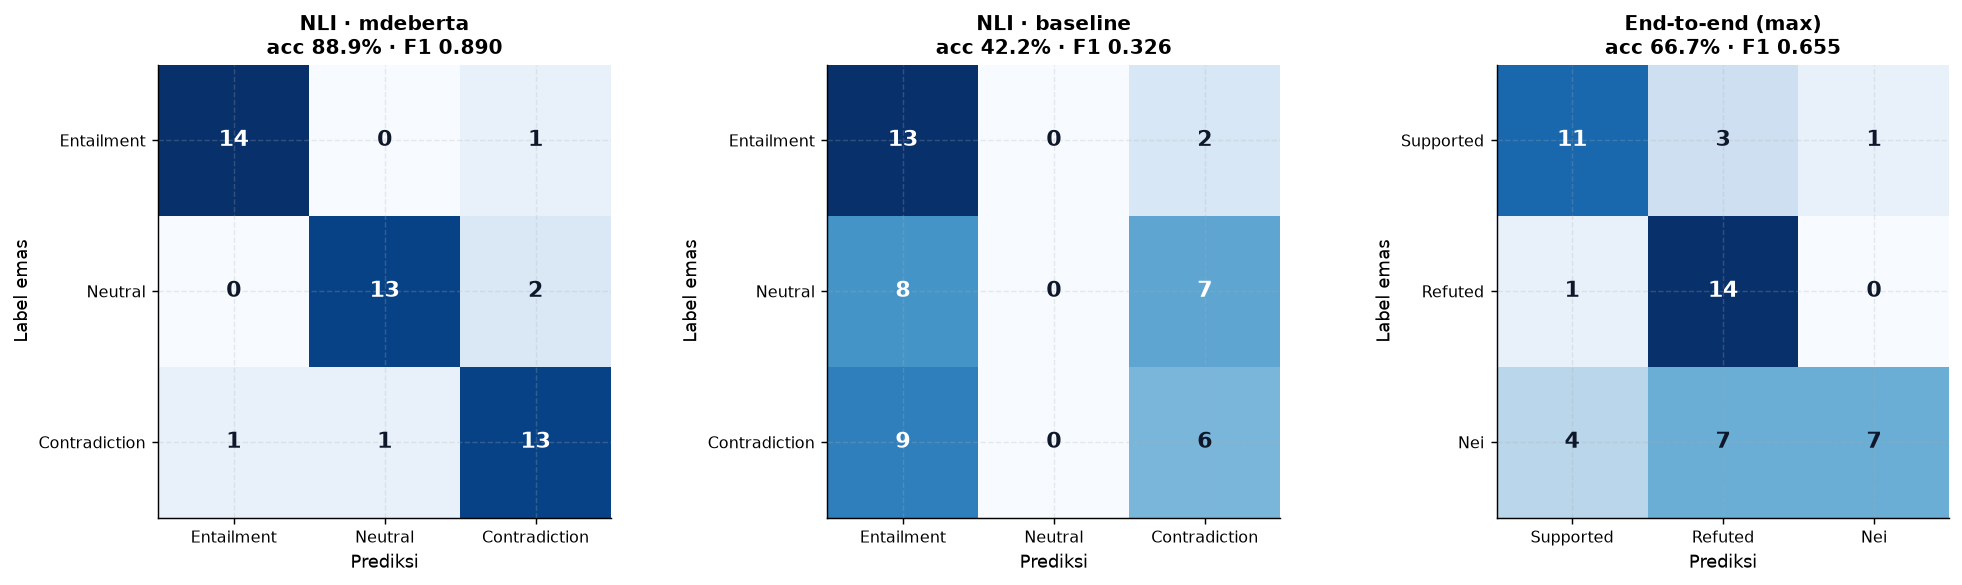

Laporan tersimpan:
  • reports\evaluation_results.json
  • reports\confusion_matrices.png
  • reports\evaluation_summary.md


In [18]:
paths = save_report(results, ROOT / "reports")
display(Image(filename=str(paths["confusion"]), width=1100))
print("Laporan tersimpan:", *[p.relative_to(ROOT) for p in paths.values()], sep="\n  • ")

## 11. Analisis Sensitivitas & Kesalahan
### 11.1 Sensitivitas ambang keputusan
Hasil NLI per evidence dari Bagian 10.3 dipakai ulang, sehingga seluruh sweep tidak memerlukan inferensi ulang.

In [19]:
from fact_checker.aggregation import aggregate

def sweep(param, values):
    out = []
    for val in values:
        kw = dict(relevance_threshold=cfg.relevance_threshold, support_threshold=cfg.support_threshold,
                  refute_threshold=cfg.refute_threshold)
        if param == "decision":
            kw["support_threshold"] = kw["refute_threshold"] = val
        else:
            kw["relevance_threshold"] = val
        y_true = [c.verdict for c, _ in runs]
        y_pred = [aggregate(r.evidences, "max", **kw).label for _, r in runs]
        m = classification_metrics(y_true, y_pred, VERDICTS)
        out.append({"nilai": val, "Accuracy": m["accuracy"], "Macro-F1": m["macro_f1"]})
    return pd.DataFrame(out).set_index("nilai")

s_dec = sweep("decision", np.round(np.arange(0.40, 0.96, 0.05), 2))
s_rel = sweep("relevance", np.round(np.arange(0.20, 0.66, 0.05), 2))
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
for ax, df_, cur, title in [(axes[0], s_dec, cfg.support_threshold, "Ambang keputusan τ (support = refute)"),
                            (axes[1], s_rel, cfg.relevance_threshold, "Ambang relevansi τ_rel")]:
    ax.plot(df_.index, df_["Accuracy"], "o-", color=C["blue"], label="Accuracy")
    ax.plot(df_.index, df_["Macro-F1"], "s--", color=C["violet"], label="Macro-F1")
    ax.axvline(cur, color=C["red"], ls=":", label=f"dipakai = {cur}")
    ax.set_title(title); ax.set_xlabel("nilai ambang"); ax.legend(frameon=False)
axes[0].set_ylim(0, 1.05); plt.tight_layout(); plt.show()

> Ambang dipilih berdasarkan prior yang masuk akal (bukan di-*tune* pada benchmark) untuk menghindari
> overfitting pada 48 kasus. Kurva di atas menunjukkan seberapa stabil performa terhadap pilihan tersebut.

### 11.2 Analisis kesalahan

In [20]:
err = pd.DataFrame([d for d in e2e["strategies"]["max"]["predictions"] if d["gold"] != d["pred"]])
if len(err):
    err["confidence"] = err["confidence"].map("{:.0%}".format)
    display(err[["id", "topic", "claim", "gold", "pred", "confidence", "evidence_hit"]]
            .style.map(color_verdict, subset=["gold", "pred"]).hide(axis="index"))
else:
    print("Tidak ada kesalahan prediksi.")

id,topic,claim,gold,pred,confidence,evidence_hit
1,Kebakaran Plumpang: instruksi Presiden,Presiden Jokowi memerintahkan Wakil Presiden Ma'ruf Amin meninjau lokasi kebakaran Depo Pertamina Plumpang.,SUPPORTED,REFUTED,66%,True
3,Kebakaran Plumpang: instruksi Presiden,Wakil Presiden Ma'ruf Amin meninjau lokasi kebakaran Plumpang bersama Gubernur Jawa Barat Ridwan Kamil.,NOT_ENOUGH_INFO,REFUTED,91%,True
6,Kebakaran Plumpang: jumlah korban,Kebakaran Depo Plumpang dipastikan disebabkan oleh sambaran petir.,NOT_ENOUGH_INFO,REFUTED,100%,False
9,Putusan penundaan Pemilu: banding KPU,Pengadilan Tinggi DKI Jakarta telah mengabulkan banding yang diajukan KPU.,NOT_ENOUGH_INFO,SUPPORTED,100%,False
12,Tragedi Kanjuruhan: vonis Ketua Panpel,Abdul Haris langsung mengajukan banding ke Pengadilan Tinggi Jawa Timur setelah vonis dibacakan.,NOT_ENOUGH_INFO,REFUTED,95%,False
16,Erupsi Gunung Merapi 11 Maret,Warga diminta menjauhi radius 7 km dari puncak Merapi setelah awan panas guguran pada 11 Maret 2023.,SUPPORTED,NOT_ENOUGH_INFO,49%,True
21,Transaksi janggal Rafael Alun,Rafael Alun Trisambodo telah divonis 14 tahun penjara oleh Pengadilan Tipikor.,NOT_ENOUGH_INFO,SUPPORTED,69%,False
23,Kasus Mario Dandy: restorative justice,Kejati DKI Jakarta menyetujui penyelesaian kasus Mario Dandy melalui restorative justice.,REFUTED,SUPPORTED,99%,False
33,Proyeksi pemudik Lebaran 2023,Pemerintah memberlakukan larangan mudik bagi aparatur sipil negara pada Lebaran 2023.,NOT_ENOUGH_INFO,SUPPORTED,98%,False
36,Program mudik gratis Kemenhub,Pendaftaran mudik gratis Kemenhub hanya dapat dilakukan melalui kantor pos.,NOT_ENOUGH_INFO,REFUTED,100%,False


Pola kesalahan yang umum pada sistem NLI-based fact-checking:
* **Klaim netral yang terdengar spesifik** (angka, lokasi, pihak tertentu) kadang dibaca model sebagai
  *contradiction* karena detailnya berbeda dari evidence — padahal evidence hanya *tidak menyebut*.
* **Evidence tidak terambil** (`evidence_hit = False`): kesalahan pada tahap retrieval merambat ke verdict.
* **Negasi & kuantor** ("tidak ada satu pun", "tetap") masih menjadi titik lemah model.

## 12. Web App
Dashboard Gradio menampilkan verdict, kartu evidence (dengan tautan sumber), highlight SHAP, dan hasil
evaluasi. Jalankan dari terminal:
```bash
python -m fact_checker app
```
atau hapus tanda komentar pada sel berikut.

In [21]:
# import gradio as gr
# from fact_checker.app import build_app, CSS
# build_app(fc).queue().launch(theme=gr.themes.Soft(primary_hue="blue"), css=CSS)

## 13. Kesimpulan

In [22]:
nli_new, nli_old = results["nli"]["indobert"], results["nli"]["baseline"]
best_ret = max(results["retrieval"], key=lambda k: results["retrieval"][k]["mrr"])
e_max, e_mean = e2e["strategies"]["max"], e2e["strategies"]["mean"]
display(Markdown(f'''
| Temuan | Hasil |
|---|---|
| IndoBERT & Entailment Verification (NLI) vs baseline English-only | Macro-F1 **{nli_old["macro_f1"]:.3f} → {nli_new["macro_f1"]:.3f}**, accuracy {nli_old["accuracy"]:.1%} → **{nli_new["accuracy"]:.1%}** |
| Retrieval terbaik (MRR) | **{best_ret}** — MRR {results["retrieval"][best_ret]["mrr"]:.3f}, Recall@5 {results["retrieval"][best_ret]["recall@5"]:.1%} |
| End-to-end (agregasi max) | accuracy **{e_max["accuracy"]:.1%}**, Macro-F1 **{e_max["macro_f1"]:.3f}** |
| Agregasi max vs mean (versi lama) | Macro-F1 {e_mean["macro_f1"]:.3f} → **{e_max["macro_f1"]:.3f}** |
| Latensi | {e2e["seconds_per_claim"]:.2f} detik/klaim di {resolve_device().upper()} (tanpa SHAP) |
'''))


| Temuan | Hasil |
|---|---|
| IndoBERT & Entailment Verification (NLI) vs baseline English-only | Macro-F1 **0.326 → 0.890**, accuracy 42.2% → **88.9%** |
| Retrieval terbaik (MRR) | **hybrid** — MRR 0.398, Recall@5 53.3% |
| End-to-end (agregasi max) | accuracy **66.7%**, Macro-F1 **0.655** |
| Agregasi max vs mean (versi lama) | Macro-F1 0.686 → **0.655** |
| Latensi | 14.43 detik/klaim di CPU (tanpa SHAP) |


1. **Pemilihan model NLI adalah faktor paling menentukan.** Model English-only gagal total pada bahasa
   Indonesia (tidak pernah memprediksi *neutral* dan menganggap banyak hoaks sebagai *entailment*).
   IndoBERT NLI yang dilatih pada data IndoBERT & Entailment Verification (NLI) menyelesaikan masalah tersebut.
2. **Hybrid retrieval** menggabungkan kekuatan pencocokan leksikal (nama tokoh, angka) dan semantik
   (parafrase) sehingga artikel emas lebih konsisten berada di peringkat atas.
3. **Passage selection + agregasi max** membuat keputusan bertumpu pada kalimat bukti yang spesifik,
   dan bukti kuat tidak diencerkan oleh evidence yang tidak relevan.
4. **SHAP** menunjukkan bahwa model memusatkan perhatian pada kata yang secara logis menentukan
   (mis. *memerintahkan* vs *melarang*), meningkatkan kepercayaan terhadap sistem.

**Keterbatasan & pengembangan lanjutan**
* Korpus terbatas Maret–April 2023; perlu pembaruan korpus berkala / pencarian web langsung.
* Benchmark 48 kasus masih kecil → perlu anotasi lebih besar dan evaluasi pada IndoNLI.
* *Fine-tuning* model NLI pada IndoNLI (Mahendra et al., 2021) dan *cross-encoder reranker* untuk passage
  berpotensi meningkatkan performa lebih lanjut.
* "Didukung berita" ≠ "pasti benar": sistem memeriksa konsistensi terhadap korpus, bukan kebenaran absolut.

**Referensi**
* Thorne et al. (2018). *FEVER: a large-scale dataset for Fact Extraction and VERification.* NAACL.
* He et al. (2021). *IndoBERT: Improving IndoBERT using ELECTRA-Style Pre-Training.* arXiv:2111.09543.
* Laurer et al. (2022). *Less Annotating, More Classifying* — model `LazarusNLP/indobert-lite-base-p1-indonli` (IndoBERT NLI).
* Reimers & Gurevych (2019/2020). *Sentence-BERT* & *Making Monolingual Sentence Embeddings Multilingual.*
* Robertson & Zaragoza (2009). *The Probabilistic Relevance Framework: BM25 and Beyond.*
* Cormack, Clarke & Büttcher (2009). *Reciprocal Rank Fusion outperforms Condorcet and individual rank learning methods.* SIGIR.
* Lundberg & Lee (2017). *A Unified Approach to Interpreting Model Predictions (SHAP).* NeurIPS.
* Mahendra et al. (2021). *IndoNLI: A Natural Language Inference Dataset for Indonesian.* EMNLP.